# 四目标：先选择访问顺序，再由 SFP 执行（single 数据）

本实验使用已有 `datasets/v1`，不需要 multi 数据。比较三种情况：

| 名称 | 速度场 | 执行期间的路线条件 | 用途 |
|---|---|---|---|
| `baseline` | single SFP | 全零 | 原方法的对照 |
| `oracle_order` | 路线条件 SFP | 专家访问顺序，固定一次 | 仅作诊断参照，包含测试时专家信息 |
| `predicted_order` | 同一个路线条件 SFP | 选择器根据布局预测，固定一次 | 正式方法结果 |

**固定输入顺序不保证模型一定遵循它。** 本文件同时测量选择质量、实际覆盖率和可判定情况下的顺序一致率。
保留原来的全程时间 `t∈[0,1]`、训练噪声、速度监督和固定起点 RK4 执行；没有强制连接目标、吸附到目标、额外执行时间或动态访问记录。
两个 SFP 的主干和参数数目相同，额外路线投影在 baseline 中接收全零输入。Oracle 与 predicted 共享完全相同的 SFP 权重。

**运行方法：** 将此文件放在原仓库内，使用原先能够运行训练的 Python 环境，依次运行单元格。
找不到数据时，在第一个代码单元设置 `PROJECT_ROOT_OVERRIDE`。不会改写旧数据或旧实验。
默认是 seed 0、两个 SFP 各 1,000 epochs 的试跑；选择器单独训练 500 epochs（每 epoch 20 次更新）。
`SFP_BUDGETS=[10000]` 可进行原预算实验；`SEEDS=[0,1,2]` 可扩展种子。改变总预算会开启独立训练，不能沿用不同余弦学习率计划的中途状态。
同预算旧 single 最终模型经配置检查后可复用；否则训练匹配的 baseline。重复运行会自动续训或复用已完成结果。

这是一个“学习路线选择器 + 路线条件 SFP”的诊断/扩展，不等同于原 SFP 独立解决规划。
本文件已做静态代码检查；没有在交付前运行训练或推理。
方法背景：[SFP](https://arxiv.org/abs/2505.21851)，[神经路线规划](https://arxiv.org/abs/1803.08475)。


In [1]:
from pathlib import Path
import hashlib, itertools, json, os, platform, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display

PROJECT_ROOT_OVERRIDE = None  # Example: Path(r'D:/projects/streaming-flow-policy')
EXPERIMENT_TAG = 'single_route_choice_v1'
SFP_BUDGETS = [1000]
SEEDS = [0]
SELECTOR_EPOCHS = 500
SELECTOR_STEPS_PER_EPOCH = 20
SELECTOR_BATCH_SIZE = 1024
REUSE_OLD_SINGLE = True
CHECKPOINT_EVERY = 25
PROBE_EVERY = 25
EVAL_STEPS = 1000
EVAL_BATCH_SIZE = 100
VISIT_TOLERANCES = [0.02, 0.05]
NEAROPT_SLACK = 0.05  # Evaluation threshold only; does NOT add near-optimal training routes.
PLOT_SEED = SEEDS[0]
FIXED_PLOT_LAYOUTS = [12, 20, 281, 954]  # Zero-based row IDs, as in the previous diagnostics.

PROTOCOL = 'single_route_choice_v1_20260930'
BASE_CONFIG = dict(input_preprocessing='sort_targets_by_x_then_y',
    num_training_layouts=10000, validation_probe_seed=500, validation_probe_size=20000,
    steps_per_epoch=100, batch_size=2048, learning_rate=1e-3, weight_decay=1e-6,
    hidden_dim=128, num_hidden_layers=4, sigma_0=0.05, stabilizing_gain=2.5)
PERMS = np.asarray(list(itertools.permutations(range(4))), dtype=np.int64)
PLAN_CODES = np.eye(4, dtype=np.float32)[PERMS].reshape(24, 16)
CASES = ['baseline', 'oracle_order', 'predicted_order']
GAP_LABELS = ['<1%', '1-<5%', '5-<10%', '>=10%']
COLORS = dict(baseline='tab:blue', oracle_order='tab:green', predicted_order='tab:orange')

def find_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        root = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
    else:
        here = Path.cwd().resolve()
        candidates = [here, *here.parents]
        root = next((p for p in candidates if
            (p/'experiments/four_boxes_experiments/four_targets/datasets/v1/train.npz').is_file()), None)
        if root is None:
            raise FileNotFoundError('Set PROJECT_ROOT_OVERRIDE to the repository containing datasets/v1.')
    return root

assert SFP_BUDGETS and len(set(SFP_BUDGETS)) == len(SFP_BUDGETS)
assert SEEDS and len(set(SEEDS)) == len(SEEDS)
assert all(isinstance(x, int) and x > 0 for x in SFP_BUDGETS)
assert all(isinstance(x, int) and x >= 0 for x in SEEDS)
assert all(x > 0 for x in [SELECTOR_EPOCHS, SELECTOR_STEPS_PER_EPOCH,
    SELECTOR_BATCH_SIZE, CHECKPOINT_EVERY, PROBE_EVERY, EVAL_STEPS, EVAL_BATCH_SIZE])
assert set(VISIT_TOLERANCES) == {0.02, 0.05}
assert PLOT_SEED in SEEDS
PROJECT_ROOT = find_root()
TASK_ROOT = PROJECT_ROOT/'experiments/four_boxes_experiments/four_targets'
DATA_DIR = TASK_ROOT/'datasets/v1'
RUN_ROOT = TASK_ROOT/'runs'/EXPERIMENT_TAG
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project:', PROJECT_ROOT, '\nData:', DATA_DIR, '\nOutput:', RUN_ROOT, '\nDevice:', DEVICE)
print('SFP updates per model:', {b: b*BASE_CONFIG['steps_per_epoch'] for b in SFP_BUDGETS})
print('Selector updates per seed:', SELECTOR_EPOCHS*SELECTOR_STEPS_PER_EPOCH)
print('Each seed/budget has two SFP trainings; oracle/predicted share one of them.')
if DEVICE.type == 'cpu':
    print('CUDA unavailable. Check the notebook kernel before starting a long training run.')


Project: /home/matcho/projects/streaming-flow-policy 
Data: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/datasets/v1 
Output: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/single_route_choice_v1 
Device: cuda
SFP updates per model: {1000: 100000}
Selector updates per seed: 10000
Each seed/budget has two SFP trainings; oracle/predicted share one of them.


## 读取 single 数据，统一路线编号
目标点按 x、y 排序后定义内部编号，避免“输入排序了、路线标签没有同步”的错误。
模型内部使用这些规范编号；CSV 的 `*_order_original` 和轨迹图使用原数据中的 1–4 号。
训练标签从保存的专家路线提取。枚举 24 条路线只用于数据完整性检查与评价；选择器的训练损失仅使用 single 的顺序标签。
验证集沿用原来的 1,000 个布局，属于开发对照，不作为全新独立测试集。


In [2]:
def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024*1024), b''):
            h.update(block)
    return h.hexdigest()

def array_digest(a):
    a = np.ascontiguousarray(a)
    h = hashlib.sha256(str((a.shape, a.dtype.str)).encode())
    h.update(a.tobytes())
    return h.hexdigest()

def load_single(path, expected_n):
    with np.load(path, allow_pickle=False) as z:
        s = {k: z[k].copy() for k in z.files}
    n = len(s['targets'])
    if n != expected_n:
        raise ValueError(f'{path.name}: expected {expected_n} layouts, got {n}')
    shapes = dict(starts=(n,2), targets=(n,4,2), conditions=(n,10),
                  routes=(n,5,2), knot_tau=(n,5), lengths=(n,))
    for key, shape in shapes.items():
        if s[key].shape != shape or not np.isfinite(s[key]).all():
            raise ValueError(f'Invalid array: {key}')
    np.testing.assert_array_equal(s['conditions'], np.concatenate(
        [s['starts'], s['targets'].reshape(n,8)], axis=1))
    np.testing.assert_allclose(s['routes'][:,0], s['starts'], rtol=0, atol=1e-7)
    segment_lengths = np.linalg.norm(np.diff(s['routes'], axis=1), axis=2)
    if np.any(segment_lengths <= 0) or np.any(np.diff(s['knot_tau'], axis=1) <= 0):
        raise ValueError('Expert routes must have positive segment lengths/durations.')
    np.testing.assert_allclose(segment_lengths.sum(axis=1), s['lengths'], rtol=2e-6, atol=1e-7)
    expected_knots = np.concatenate([np.zeros((n,1)), np.cumsum(segment_lengths, axis=1)], axis=1)
    expected_knots /= expected_knots[:,-1:]
    np.testing.assert_allclose(s['knot_tau'], expected_knots, rtol=2e-6, atol=1e-7)
    row = np.arange(n)[:,None]
    distances = np.linalg.norm(s['routes'][:,1:,None,:]-s['targets'][:,None,:,:], axis=-1)
    original_order = distances.argmin(axis=2)
    if np.any(distances.min(axis=2) > 1e-7):
        raise ValueError('An expert waypoint does not match a target.')
    np.testing.assert_array_equal(np.sort(original_order, axis=1), np.broadcast_to(np.arange(4), (n,4)))
    canonical_to_original = np.lexsort((s['targets'][:,:,1], s['targets'][:,:,0]), axis=1)
    targets32 = s['targets'].astype(np.float32)
    order32 = np.lexsort((targets32[:,:,1], targets32[:,:,0]), axis=1)
    if not np.array_equal(canonical_to_original, order32):
        raise ValueError('Canonical target order changes after float32 rounding. '
            'This dataset needs consistent higher-precision preprocessing before this experiment.')
    original_to_canonical = np.empty_like(canonical_to_original)
    original_to_canonical[row, canonical_to_original] = np.arange(4)
    canonical_targets = s['targets'][row, canonical_to_original]
    canonical_order = original_to_canonical[row, original_order]
    matches = (canonical_order[:,None,:] == PERMS[None,:,:]).all(axis=2)
    assert np.all(matches.sum(axis=1) == 1)
    expert_class = matches.argmax(axis=1).astype(np.int64)
    all_lengths = []
    for order in PERMS:
        vertices = np.concatenate([s['starts'][:,None,:], canonical_targets[:,order,:]], axis=1)
        all_lengths.append(np.linalg.norm(np.diff(vertices, axis=1), axis=2).sum(axis=1))
    all_lengths = np.stack(all_lengths, axis=1)
    sorted_lengths = np.sort(all_lengths, axis=1)
    np.testing.assert_allclose(s['lengths'], sorted_lengths[:,0], rtol=2e-6, atol=1e-7)
    np.testing.assert_allclose(all_lengths[np.arange(n), expert_class], s['lengths'], rtol=2e-6, atol=1e-7)
    s.update(canonical_to_original=canonical_to_original,
        canonical_targets=canonical_targets, expert_class=expert_class,
        canonical_conditions=np.concatenate([s['starts'],canonical_targets.reshape(n,8)],axis=1),
        all_route_lengths=all_lengths, optimal_length=sorted_lengths[:,0],
        gap_percent=100*(sorted_lengths[:,1]-sorted_lengths[:,0])/sorted_lengths[:,0])
    return s

TRAIN = load_single(DATA_DIR/'train.npz', 10000)
VAL = load_single(DATA_DIR/'validation.npz', 1000)
DATA_HASHES = {name: sha256_file(DATA_DIR/name) for name in ['train.npz','validation.npz']}
np.testing.assert_allclose(VAL['starts'], np.broadcast_to(TRAIN['starts'][0], VAL['starts'].shape))
train_keys = {tuple(row) for row in TRAIN['canonical_conditions']}
if any(tuple(row) in train_keys for row in VAL['canonical_conditions']):
    raise ValueError('Exact train/validation layout overlap detected.')
label_counts = np.bincount(TRAIN['expert_class'], minlength=24)
print('Loaded 10,000 training layouts and 1,000 validation layouts. Test split not loaded.')
print('Training class counts:', label_counts.tolist())
print('Unused classes:', np.flatnonzero(label_counts == 0).tolist())

def order_original(split, i, class_id):
    return split['canonical_to_original'][i, PERMS[int(class_id)]]

def order_text(indices):
    return '>'.join(str(int(x)+1) for x in indices)

def gap_labels(values):
    return np.asarray(GAP_LABELS)[np.searchsorted([1.,5.,10.], values, side='right')]


Loaded 10,000 training layouts and 1,000 validation layouts. Test split not loaded.
Training class counts: [1562, 354, 258, 279, 74, 153, 1094, 102, 109, 400, 32, 566, 561, 25, 344, 135, 101, 1126, 160, 87, 295, 286, 373, 1524]
Unused classes: []


## 两个 SFP 主干相同；选择器只看布局
SFP 的原始输入仍是 `[a_x,a_y,t,start_x,start_y,4个目标坐标]`。路线条件是 4×4 的排列矩阵，展平为 16 维。
路线投影初始为零，保证相同 seed 的两个新 SFP 在初始化时函数相同；baseline 的路线输入始终为零。
选择器输出 24 个类别的 logits；执行前取一次 argmax，不把多条路线的坐标/速度按概率平均。


In [3]:
def canonicalize_box_inputs(inputs):
    boxes = inputs[:,5:].reshape(-1,4,2)
    for coordinate in [1,0]:
        order = torch.argsort(boxes[:,:,coordinate], dim=1, stable=True)
        boxes = torch.gather(boxes, 1, order.unsqueeze(-1).expand(-1,-1,2))
    return torch.cat([inputs[:,:5], boxes.reshape(-1,8)], dim=1)

class VelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers, width = [], 13
        hidden = BASE_CONFIG['hidden_dim']
        for _ in range(BASE_CONFIG['num_hidden_layers']):
            layers.extend([nn.Linear(width,hidden), nn.SiLU()])
            width = hidden
        layers.append(nn.Linear(width,2))
        self.network = nn.Sequential(*layers)
        self.route_projection = nn.Linear(16,hidden,bias=False)
        nn.init.zeros_(self.route_projection.weight)

    def forward(self, inputs, plan):
        normalized = 2.0*canonicalize_box_inputs(inputs)-1.0
        h = self.network[0](normalized) + self.route_projection(plan)
        for layer in list(self.network.children())[1:]:
            h = layer(h)
        return h

class RouteSelector(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(10,128), nn.SiLU(),
            nn.Linear(128,128), nn.SiLU(), nn.Linear(128,128), nn.SiLU(), nn.Linear(128,24))

    def forward(self, canonical_conditions):
        return self.network(2.0*canonical_conditions-1.0)

def sample_single_batch(split, batch_size, rng):
    ids = rng.integers(0, len(split['targets']), size=batch_size)
    routes, knots = split['routes'][ids], split['knot_tau'][ids]
    tau = rng.uniform(0.,1.,size=batch_size)
    segments = np.clip((tau[:,None] >= knots[:,1:]).sum(axis=1),0,3)
    row = np.arange(batch_size)
    p0, p1 = routes[row,segments], routes[row,segments+1]
    t0 = knots[row,segments]
    duration = knots[row,segments+1]-t0
    position = p0 + ((tau-t0)/duration)[:,None]*(p1-p0)
    derivative = (p1-p0)/duration[:,None]
    gain, sigma = BASE_CONFIG['stabilizing_gain'], BASE_CONFIG['sigma_0']
    noise = (sigma*np.exp(-gain*tau))[:,None]*rng.standard_normal((batch_size,2))
    x = np.concatenate([position+noise,tau[:,None],split['conditions'][ids]],axis=1).astype(np.float32)
    y = (derivative-gain*noise).astype(np.float32)
    return x, y, split['expert_class'][ids]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_model(role):
    return RouteSelector() if role == 'selector' else VelocityMLP()

def plan_array(classes, role):
    return np.zeros((len(classes),16),np.float32) if role == 'baseline' else PLAN_CODES[classes]


## 训练、断点续训和旧 baseline 复用
配置只记录数据哈希和实验参数，不把电脑路径或 GPU 型号作为相等性要求。可复制整个实验目录到另一台电脑续训，但不承诺不同硬件之间逐位一致。
每 25 epochs 保存最新完整状态；最终模型固定采用最后一轮，验证结果只作监控。
旧 baseline 必须同时满足数据、预算、seed、主干和原训练参数检查。不会借用不同预算模型来冒充公平对照。
仅加载你自己生成的可信 `.pt` 文件，使用 `weights_only=True`。


In [4]:
def atomic_json(value, path):
    path = Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    tmp = path.with_name(path.name+'.tmp')
    tmp.write_text(json.dumps(value,indent=2,ensure_ascii=False,allow_nan=False),encoding='utf-8')
    os.replace(tmp,path)

def atomic_torch(value, path):
    path = Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    tmp = path.with_name(path.name+'.tmp')
    torch.save(value,tmp); os.replace(tmp,path)

def atomic_npz(path, **arrays):
    path = Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    tmp = path.with_name(path.name+'.tmp')
    with tmp.open('wb') as f:
        np.savez_compressed(f,**arrays)
    os.replace(tmp,path)

def cpu_state(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

def config_for(role, budget, seed):
    cfg = dict(protocol=PROTOCOL,role=role,training_seed=int(seed),num_epochs=int(budget),
        dataset_sha256=DATA_HASHES,selection='final_epoch',route_encoding='canonical_4x4_one_hot',
        initializer='original_backbone_then_zero_route_projection',training_data='single_only')
    if role == 'selector':
        cfg.update(steps_per_epoch=SELECTOR_STEPS_PER_EPOCH,batch_size=SELECTOR_BATCH_SIZE,
            learning_rate=1e-3,weight_decay=1e-6,train_sampling_seed=30000+seed,
            initialization_seed=20000+seed,hidden_dim=128,num_hidden_layers=3,
            loss='cross_entropy_saved_single_expert_order')
    else:
        cfg.update(BASE_CONFIG,train_sampling_seed=1000+seed,initialization_seed=seed,
            loss='single_expert_conditional_velocity_mse')
    return cfg

def require_same(saved,current):
    if saved != current:
        diff = {k:[saved.get(k),current.get(k)] for k in set(saved)|set(current) if saved.get(k)!=current.get(k)}
        raise ValueError('Configuration changed. Choose a new EXPERIMENT_TAG. Differences: '+str(diff))

def run_directory(role,budget,seed):
    if role == 'selector':
        return RUN_ROOT/f'selector_epochs_{budget}'/f'seed_{seed}'
    return RUN_ROOT/f'budget_{budget}'/f'seed_{seed}'/role

def find_old_baseline(budget,seed):
    if not REUSE_OLD_SINGLE:
        return None
    dirs = [TASK_ROOT/'runs/single_vs_multi_05pct_v1'/f'budget_{budget}_seed_{seed}_single',
        TASK_ROOT/'runs/conditional_mlp_canonical_seed_sweep'/f'budget_{budget}_seed_{seed}']
    if seed == 0:
        dirs.append(TASK_ROOT/'runs'/f'conditional_mlp_canonical_{budget}epochs_v1_seed0')
    expected = {**BASE_CONFIG,'training_seed':seed,'train_sampling_seed':1000+seed,
        'num_epochs':budget,'dataset_sha256':DATA_HASHES}
    for folder in dirs:
        for name in ['final.pt','latest.pt']:
            path = folder/name
            if not path.is_file():
                continue
            ckpt = torch.load(path,map_location='cpu',weights_only=True)
            cfg = ckpt.get('config',{})
            differing = [k for k,v in expected.items() if cfg.get(k)!=v]
            if ckpt.get('epoch')!=budget or differing or cfg.get('sampling','single')!='single':
                print('[skip old baseline]',path,'different:',differing,'epoch:',ckpt.get('epoch'))
                continue
            model = VelocityMLP()
            expected_keys = set(model.network.state_dict())
            raw = ckpt.get('model',{})
            if set(raw) != {'network.'+k for k in expected_keys}:
                print('[skip old baseline] Unexpected architecture:',path); continue
            model.network.load_state_dict({k:raw['network.'+k] for k in expected_keys},strict=True)
            return path, cpu_state(model), ckpt.get('history',{})
    return None

@torch.no_grad()
def predict_classes(model,canonical_conditions,batch_size=1024):
    # This function receives layout coordinates ONLY, never expert labels or route lengths.
    model.eval(); p = next(model.parameters()); outputs=[]
    for lo in range(0,len(canonical_conditions),batch_size):
        x = torch.as_tensor(canonical_conditions[lo:lo+batch_size],dtype=p.dtype,device=p.device)
        logits = model(x)
        if not torch.isfinite(logits).all():
            raise RuntimeError('Non-finite selector logits.')
        outputs.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(outputs).astype(np.int64)

def selector_table(classes,seed):
    n=len(classes); planned=VAL['all_route_lengths'][np.arange(n),classes]
    excess=np.maximum(0.,100*(planned/VAL['optimal_length']-1))
    return pd.DataFrame(dict(seed=seed,layout_index=np.arange(n),predicted_class=classes,
        expert_class=VAL['expert_class'],label_match=classes==VAL['expert_class'],
        predicted_length=planned,optimal_length=VAL['optimal_length'],excess_percent=excess,
        near_optimal=excess<=100*NEAROPT_SLACK+1e-7,
        gap_percent=VAL['gap_percent'],gap_bin=gap_labels(VAL['gap_percent']),
        predicted_order_original=[order_text(order_original(VAL,i,c)) for i,c in enumerate(classes)],
        expert_order_original=[order_text(order_original(VAL,i,c)) for i,c in enumerate(VAL['expert_class'])]))

@torch.no_grad()
def probe_model(model,role,probe):
    model.eval()
    if role == 'selector':
        x=torch.as_tensor(VAL['canonical_conditions'],dtype=torch.float32,device=DEVICE)
        y=torch.as_tensor(VAL['expert_class'],dtype=torch.long,device=DEVICE)
        logits=model(x); loss=nn.functional.cross_entropy(logits,y)
        classes=logits.argmax(dim=1).cpu().numpy()
        table=selector_table(classes,0)
        result=dict(loss=float(loss.item()),label_accuracy=float(table.label_match.mean()),
            nearopt_rate=float(table.near_optimal.mean()),mean_excess_percent=float(table.excess_percent.mean()))
    else:
        x,y,plan=probe; total=0.
        for lo in range(0,len(x),4096):
            hi=min(lo+4096,len(x)); loss=nn.functional.mse_loss(model(x[lo:hi],plan[lo:hi]),y[lo:hi])
            total+=float(loss.item())*(hi-lo)
        result=dict(loss=total/len(x))
    if not all(np.isfinite(v) for v in result.values()):
        raise RuntimeError('Non-finite validation probe.')
    return result

def train_or_resume(role,budget,seed):
    config=config_for(role,budget,seed); folder=run_directory(role,budget,seed)
    folder.mkdir(parents=True,exist_ok=True)
    config_path=folder/'config.json'; final=folder/'final.pt'; latest=folder/'latest.pt'
    if config_path.exists():
        require_same(json.loads(config_path.read_text(encoding='utf-8')),config)
    else:
        atomic_json(config,config_path)
    if final.exists():
        ckpt=torch.load(final,map_location='cpu',weights_only=True)
        require_same(ckpt['config'],config)
        if ckpt['epoch']!=budget:
            raise ValueError('Unexpected final checkpoint epoch.')
        print(f'[complete] {role}, seed={seed}, epochs={budget}'); return folder
    if role=='baseline' and not latest.exists():
        old=find_old_baseline(budget,seed)
        if old is not None:
            source,state,history=old
            atomic_torch(dict(model=state,epoch=budget,config=config,history=history,
                provenance=dict(reused_old_final=True,source=source.relative_to(PROJECT_ROOT).as_posix(),
                    sha256=sha256_file(source))),final)
            print('[reuse baseline]',source); return folder
    set_seed(config['initialization_seed'])
    model=make_model(role).to(device=DEVICE,dtype=torch.float32)
    optimizer=torch.optim.AdamW(model.parameters(),lr=config['learning_rate'],weight_decay=config['weight_decay'])
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=budget)
    rng=np.random.default_rng(config['train_sampling_seed'])
    history=dict(epoch=[],train_loss=[],probe_epoch=[],probe_loss=[],selector_accuracy=[],
                 selector_nearopt_rate=[],selector_mean_excess_percent=[])
    start_epoch=0
    if latest.exists():
        ckpt=torch.load(latest,map_location='cpu',weights_only=True)
        require_same(ckpt['config'],config)
        model.load_state_dict(ckpt['model'],strict=True); optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler']); rng.bit_generator.state=ckpt['numpy_rng_state']
        random.setstate(ckpt['python_rng_state']); torch.set_rng_state(ckpt['torch_rng_state'])
        if DEVICE.type=='cuda' and len(ckpt['cuda_rng_states'])==torch.cuda.device_count():
            torch.cuda.set_rng_state_all(ckpt['cuda_rng_states'])
        history=ckpt['history']; start_epoch=int(ckpt['epoch'])
        if not 0<=start_epoch<=budget:
            raise ValueError('Invalid saved epoch.')
        del ckpt
    probe=None
    if role!='selector':
        px,py,pc=sample_single_batch(VAL,BASE_CONFIG['validation_probe_size'],
            np.random.default_rng(BASE_CONFIG['validation_probe_seed']))
        probe=tuple(torch.from_numpy(a).to(DEVICE) for a in [px,py,plan_array(pc,role)])
    atomic_json(dict(python=platform.python_version(),numpy=np.__version__,torch=str(torch.__version__),
        device=str(DEVICE),gpu=torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else None),folder/'environment.json')
    print(f'[train] {role}, seed={seed}, epochs {start_epoch} -> {budget}',flush=True)
    clock=time.monotonic()
    for epoch in range(start_epoch+1,budget+1):
        model.train(); total=0.
        for _ in range(config['steps_per_epoch']):
            optimizer.zero_grad(set_to_none=True)
            if role=='selector':
                ids=rng.integers(0,len(TRAIN['targets']),size=config['batch_size'])
                x=torch.as_tensor(TRAIN['canonical_conditions'][ids],dtype=torch.float32,device=DEVICE)
                y=torch.as_tensor(TRAIN['expert_class'][ids],dtype=torch.long,device=DEVICE)
                loss=nn.functional.cross_entropy(model(x),y)
            else:
                x,y,classes=sample_single_batch(TRAIN,config['batch_size'],rng)
                plan=torch.from_numpy(plan_array(classes,role)).to(DEVICE)
                x,y=torch.from_numpy(x).to(DEVICE),torch.from_numpy(y).to(DEVICE)
                loss=nn.functional.mse_loss(model(x,plan),y)
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite training loss. The last complete checkpoint remains available.')
            loss.backward(); optimizer.step(); total+=float(loss.item())
        history['epoch'].append(epoch); history['train_loss'].append(total/config['steps_per_epoch'])
        if epoch==1 or epoch%PROBE_EVERY==0 or epoch==budget:
            result=probe_model(model,role,probe)
            history['probe_epoch'].append(epoch); history['probe_loss'].append(result['loss'])
            if role=='selector':
                history['selector_accuracy'].append(result['label_accuracy'])
                history['selector_nearopt_rate'].append(result['nearopt_rate'])
                history['selector_mean_excess_percent'].append(result['mean_excess_percent'])
            eta=(time.monotonic()-clock)/(epoch-start_epoch)*(budget-epoch)
            extra=f" nearopt={100*result['nearopt_rate']:.1f}%" if role=='selector' else ''
            print(f'{role} seed={seed} epoch={epoch}/{budget} train={history["train_loss"][-1]:.6f} '
                f'probe={result["loss"]:.6f}{extra} ETA={eta/3600:.2f}h',flush=True)
        scheduler.step()
        if epoch%CHECKPOINT_EVERY==0 or epoch==budget:
            atomic_torch(dict(model=cpu_state(model),optimizer=optimizer.state_dict(),
                scheduler=scheduler.state_dict(),epoch=epoch,config=config,history=history,
                numpy_rng_state=rng.bit_generator.state,python_rng_state=random.getstate(),
                torch_rng_state=torch.get_rng_state(),
                cuda_rng_states=torch.cuda.get_rng_state_all() if DEVICE.type=='cuda' else []),latest)
            atomic_json(history,folder/'history.json')
    atomic_torch(dict(model=cpu_state(model),epoch=budget,config=config,history=history,
        provenance=dict(reused_old_final=False)),final)
    del model,optimizer,scheduler,probe
    if DEVICE.type=='cuda':
        torch.cuda.empty_cache()
    return folder

print('Training functions ready. The NEXT code cell starts training.')


Training functions ready. The NEXT code cell starts training.


## 开始训练
每个 seed 训练一个选择器；每个 SFP 预算训练/复用 baseline，并训练路线条件 SFP。
Oracle 和 predicted 是同一模型的两种评估方式，不会各训练一遍。


In [5]:
SELECTOR_RUNS={}
SFP_RUNS={}
for seed in SEEDS:
    SELECTOR_RUNS[seed]=train_or_resume('selector',SELECTOR_EPOCHS,seed)
    for budget in SFP_BUDGETS:
        for role in ['baseline','route_conditioned']:
            SFP_RUNS[(budget,seed,role)]=train_or_resume(role,budget,seed)
print('All final checkpoints are ready.')


[complete] selector, seed=0, epochs=500
[complete] baseline, seed=0, epochs=1000
[complete] route_conditioned, seed=0, epochs=1000
All final checkpoints are ready.


## 推理与指标
从同一精确起点出发，float64 RK4，固定积分至 `t=1`。路线条件在所有 RK4 子步中保持不变。
成功以实际折线是否进入每个目标的半径 0.02/0.05 判定，不要求与最优顺序一致。
选择质量是所选顺序经过目标中心的理论长度；执行质量使用实际路径，二者单独报告。
`path_length_ratio` 是完整执行轨迹长/最优中心路线长；进入目标圆盘就算访问，因此该比值可能略小于 1。
`completion_length_ratio` 在首次完成全部访问的位置截断，只对成功路径计算。
顺序一致性使用圆盘首次进入次序。若理想规划折线本身会提前进入其他目标圆盘，或进入时间并列，则标记不可判定，不影响覆盖成功率。
当前首次进入顺序诊断不证明整条几何轨迹与示范完全一致，也不能证明旧模型曾经“换路线”。
若需检查积分步数敏感性，将 `EVAL_STEPS` 改为 2000 后重跑评估部分；训练无需重跑，缓存会按步数区分。


In [6]:
def load_final_model(role,budget,seed,dtype=torch.float32):
    path=run_directory(role,budget,seed)/'final.pt'
    ckpt=torch.load(path,map_location='cpu',weights_only=True)
    require_same(ckpt['config'],config_for(role,budget,seed))
    if ckpt['epoch']!=budget:
        raise ValueError('Evaluation requires the requested final epoch.')
    model=make_model(role).to(device=DEVICE,dtype=dtype)
    model.load_state_dict(ckpt['model'],strict=True); model.eval()
    return model

@torch.no_grad()
def generate_paths(model,split,classes,num_steps=1000,batch_size=100):
    p=next(model.parameters()); outputs=[]; dt=1./num_steps
    if classes is not None:
        classes=np.asarray(classes,dtype=np.int64).copy()
        if classes.shape!=(len(split['starts']),) or np.any((classes<0)|(classes>=24)):
            raise ValueError('Expected one valid fixed route class per layout.')
        classes.flags.writeable=False
    for lo in range(0,len(split['starts']),batch_size):
        hi=min(lo+batch_size,len(split['starts']))
        conditions=torch.as_tensor(split['conditions'][lo:hi],dtype=p.dtype,device=p.device)
        actions=torch.as_tensor(split['starts'][lo:hi],dtype=p.dtype,device=p.device).clone()
        plan=np.zeros((hi-lo,16),np.float32) if classes is None else PLAN_CODES[classes[lo:hi]]
        fixed_plan=torch.as_tensor(plan,dtype=p.dtype,device=p.device)
        paths=torch.empty((hi-lo,num_steps+1,2),dtype=p.dtype,device=p.device)
        paths[:,0]=actions
        def velocity(a,tau):
            t=torch.full((len(a),1),tau,dtype=a.dtype,device=a.device)
            return model(torch.cat([a,t,conditions],dim=1),fixed_plan)
        for step in range(num_steps):
            tau=step*dt
            k1=velocity(actions,tau)
            k2=velocity(actions+dt*k1/2,tau+dt/2)
            k3=velocity(actions+dt*k2/2,tau+dt/2)
            k4=velocity(actions+dt*k3,min(tau+dt,1.))
            actions=actions+dt/6*(k1+2*k2+2*k3+k4)
            paths[:,step+1]=actions
        outputs.append(paths.cpu().numpy())
        print(f'  rollout {hi}/{len(split["starts"])}',flush=True)
    return np.concatenate(outputs)

def target_distances(path,targets):
    p0=path[:-1]; v=np.diff(path,axis=0)
    w=targets[:,None,:]-p0[None,:,:]
    denom=np.maximum(np.sum(v*v,axis=1),1e-30)
    u=np.clip(np.sum(w*v[None,:,:],axis=2)/denom[None,:],0.,1.)
    closest=p0[None,:,:]+u[:,:,None]*v[None,:,:]
    return np.linalg.norm(targets[:,None,:]-closest,axis=2).min(axis=1)

def first_entry_times(path,targets,radius):
    p0=path[:-1]; v=np.diff(path,axis=0); a=np.sum(v*v,axis=1)
    result=np.full(4,np.inf)
    for j,target in enumerate(targets):
        d=p0-target; b=2*np.sum(d*v,axis=1); c=np.sum(d*d,axis=1)-radius**2
        discriminant=b*b-4*a*c; moving=a>1e-30
        root=np.sqrt(np.maximum(discriminant,0.)); denom=np.where(moving,2*a,1.)
        enter,leave=(-b-root)/denom,(-b+root)/denom
        hit=moving & (discriminant>=0) & (leave>=0) & (enter<=1)
        u=np.where(c<=0,0.,np.where(hit,np.clip(enter,0.,1.),np.inf))
        result[j]=np.min(np.arange(len(v))+u)/(len(path)-1)
    return result

def entry_order(hits):
    finite=np.flatnonzero(np.isfinite(hits))
    order=finite[np.argsort(hits[finite],kind='stable')]
    ambiguous=bool(len(order)>1 and np.any(np.diff(hits[order])<=1e-10))
    return order,ambiguous

def length_until(path,tau):
    lengths=np.linalg.norm(np.diff(path,axis=0),axis=1)
    q=float(np.clip(tau,0.,1.))*len(lengths)
    if q>=len(lengths):
        return float(lengths.sum())
    j=int(np.floor(q))
    return float(lengths[:j].sum()+(q-j)*lengths[j])

def evaluate_paths(paths,split,classes,budget,seed,case):
    rows=[]
    for i,path in enumerate(paths):
        numeric_valid=bool(np.isfinite(path).all())
        if numeric_valid:
            with np.errstate(over='ignore',invalid='ignore',divide='ignore'):
                distances=target_distances(path,split['targets'][i])
                path_length=float(np.linalg.norm(np.diff(path,axis=0),axis=1).sum())
            numeric_valid=bool(np.isfinite(distances).all() and np.isfinite(path_length))
        if not numeric_valid:
            distances=np.full(4,np.inf); path_length=np.nan
        class_id=-1 if classes is None else int(classes[i])
        planned_order=None if classes is None else order_original(split,i,class_id)
        planned_length=np.nan if classes is None else float(split['all_route_lengths'][i,class_id])
        planned_excess=np.nan if classes is None else max(0.,100*(planned_length/split['optimal_length'][i]-1))
        for tol in VISIT_TOLERANCES:
            count=int((distances<=tol).sum()); success=numeric_valid and count==4
            actual=np.asarray([],dtype=np.int64); ambiguous=False; complete_length=np.nan
            if numeric_valid:
                hits=first_entry_times(path,split['targets'][i],tol)
                actual,ambiguous=entry_order(hits)
                if success and np.isfinite(hits).all():
                    complete_length=length_until(path,float(hits.max()))
                elif success:
                    ambiguous=True  # Preserve coverage; only order/completion extraction is unresolved.
            observable=False; followed=np.nan
            if planned_order is not None:
                vertices=np.concatenate([split['starts'][i,None,:],split['targets'][i,planned_order]],axis=0)
                ideal_hits=first_entry_times(vertices,split['targets'][i],tol)
                ideal_order,ideal_ambiguous=entry_order(ideal_hits)
                observable=bool(len(ideal_order)==4 and not ideal_ambiguous
                    and np.array_equal(ideal_order,planned_order))
                if success and observable and not ambiguous and len(actual)==4:
                    followed=float(np.array_equal(actual,planned_order))
            row=dict(budget=budget,seed=seed,case=case,layout_index=i,tolerance=tol,
                numeric_valid=numeric_valid,success=bool(success),visited_count=count,
                worst_distance=float(distances.max()),path_length=path_length,
                optimal_center_length=float(split['optimal_length'][i]),
                path_length_ratio=path_length/split['optimal_length'][i],
                completion_length_ratio=complete_length/split['optimal_length'][i],
                gap_percent=float(split['gap_percent'][i]),gap_bin=str(gap_labels(split['gap_percent'][i])),
                planned_class=class_id,planned_length=planned_length,planned_excess_percent=planned_excess,
                planned_near_optimal=np.nan if classes is None else float(planned_excess<=100*NEAROPT_SLACK+1e-7),
                planned_order_original='' if planned_order is None else order_text(planned_order),
                actual_first_entry_order_original=order_text(actual),order_ambiguous=ambiguous,
                plan_order_observable=observable,followed_plan=followed)
            for j in range(4):
                row[f'target_{j+1}_distance']=float(distances[j])
            rows.append(row)
    return pd.DataFrame(rows)

def cached_rollout(budget,seed,case,classes):
    role='baseline' if case=='baseline' else 'route_conditioned'
    final_path=run_directory(role,budget,seed)/'final.pt'
    ids=np.full(len(VAL['starts']),-1,np.int64) if classes is None else np.asarray(classes,np.int64)
    fingerprint=dict(protocol=PROTOCOL,case=case,checkpoint_sha256=sha256_file(final_path),
        validation_sha256=DATA_HASHES['validation.npz'],route_classes_sha256=array_digest(ids),
        steps=EVAL_STEPS,dtype='float64',initial_state='exact_start',integration='RK4',
        batch_size=EVAL_BATCH_SIZE)
    key=hashlib.sha256(json.dumps(fingerprint,sort_keys=True).encode()).hexdigest()[:16]
    folder=RUN_ROOT/'rollouts'/f'budget_{budget}_seed_{seed}_{case}_{key}'
    folder.mkdir(parents=True,exist_ok=True)
    path=folder/'paths.npz'; meta=folder/'metadata.json'
    reuse=False
    if path.exists() and meta.exists():
        saved=json.loads(meta.read_text(encoding='utf-8'))
        reuse=saved.get('fingerprint')==fingerprint and saved.get('sha256')==sha256_file(path)
    print(f'[evaluate] {case}, budget={budget}, seed={seed}, cached={reuse}',flush=True)
    if reuse:
        with np.load(path,allow_pickle=False) as z:
            paths=z['paths'].copy()
            np.testing.assert_array_equal(z['classes'],ids)
    else:
        model=load_final_model(role,budget,seed,dtype=torch.float64)
        paths=generate_paths(model,VAL,classes,EVAL_STEPS,EVAL_BATCH_SIZE)
        del model
        if DEVICE.type=='cuda':
            torch.cuda.empty_cache()
        atomic_npz(path,paths=paths,classes=ids,layout_indices=np.arange(len(ids)))
        atomic_json(dict(fingerprint=fingerprint,sha256=sha256_file(path)),meta)
    if paths.shape!=(len(ids),EVAL_STEPS+1,2):
        raise ValueError('Unexpected rollout cache shape.')
    bad=int((~np.isfinite(paths).all(axis=(1,2))).sum())
    if bad:
        print(f'  {bad} non-finite rollouts will count as failures, not be dropped.')
    return paths,path

def summarize(per_layout):
    rows=[]
    for (budget,seed,case,tol),group in per_layout.groupby(['budget','seed','case','tolerance'],sort=False):
        for label in ['ALL',*GAP_LABELS]:
            g=group if label=='ALL' else group[group.gap_bin==label]
            if len(g)==0:
                continue
            successful=g[g.success]; followed=g.followed_plan.dropna(); obs=g.plan_order_observable.sum()
            rows.append(dict(budget=budget,seed=seed,case=case,tolerance=tol,gap_bin=label,n_layouts=len(g),
                n_success=int(g.success.sum()),success_percent=100*g.success.mean(),mean_visited=g.visited_count.mean(),
                numeric_failure_count=int((~g.numeric_valid).sum()),
                success_mean_length_ratio=successful.path_length_ratio.mean(),
                success_mean_completion_length_ratio=successful.completion_length_ratio.mean(),
                planned_mean_excess_percent=g.planned_excess_percent.mean(),
                planned_nearopt_percent=100*g.planned_near_optimal.mean(),
                n_success_order_evaluable=len(followed),success_order_following_percent=100*followed.mean(),
                n_plan_order_observable=int(obs),
                complete_and_followed_percent_on_observable=100*(g.followed_plan==1).sum()/obs if obs else np.nan))
    return pd.DataFrame(rows)

print('Evaluation functions ready. The NEXT code cell starts inference.')


Evaluation functions ready. The NEXT code cell starts inference.


## 执行三组评估并保存 CSV
选择器只从坐标预测一次访问顺序。Oracle 顺序用于诊断和离线指标，绝不会替代 predicted 分支的预测。
文件名和缓存区分预算、seed、checkpoint、顺序和积分设置。重复执行会复用对应轨迹。


In [7]:
selector_frames=[]; PREDICTED={}; checkpoint_hashes={}
for seed in SEEDS:
    selector=load_final_model('selector',SELECTOR_EPOCHS,seed)
    PREDICTED[seed]=predict_classes(selector,VAL['canonical_conditions'])
    selector_frames.append(selector_table(PREDICTED[seed],seed))
    checkpoint_hashes[f'selector_seed_{seed}']=sha256_file(run_directory('selector',SELECTOR_EPOCHS,seed)/'final.pt')
    del selector
for budget in SFP_BUDGETS:
    for seed in SEEDS:
        for role in ['baseline','route_conditioned']:
            checkpoint_hashes[f'{role}_{budget}_{seed}']=sha256_file(run_directory(role,budget,seed)/'final.pt')
report_config=dict(protocol=PROTOCOL,budgets=SFP_BUDGETS,seeds=SEEDS,selector_epochs=SELECTOR_EPOCHS,
    checkpoints=checkpoint_hashes,data_sha256=DATA_HASHES,eval_steps=EVAL_STEPS,eval_batch=EVAL_BATCH_SIZE,
    tolerances=VISIT_TOLERANCES,nearopt_slack=NEAROPT_SLACK,selection='final_epoch',
    order_metric='first_circle_entry; exclude nonobservable ideal orders and ambiguous entries',
    validation_role='development_comparison_not_new_heldout_test')
report_id=hashlib.sha256(json.dumps(report_config,sort_keys=True).encode()).hexdigest()[:16]
REPORT_DIR=RUN_ROOT/'reports'/report_id
REPORT_DIR.mkdir(parents=True,exist_ok=True)
atomic_json(report_config,REPORT_DIR/'report_config.json')
selector_results=pd.concat(selector_frames,ignore_index=True)
selector_results.to_csv(REPORT_DIR/'selector_per_layout.csv',index=False)
selector_summary_rows=[]
for seed,g in selector_results.groupby('seed',sort=False):
    for label in ['ALL',*GAP_LABELS]:
        sub=g if label=='ALL' else g[g.gap_bin==label]
        if len(sub):
            selector_summary_rows.append(dict(seed=seed,gap_bin=label,n_layouts=len(sub),
                exact_label_accuracy_percent=100*sub.label_match.mean(),
                nearoptimal_percent=100*sub.near_optimal.mean(),
                mean_excess_percent=sub.excess_percent.mean(),median_excess_percent=sub.excess_percent.median(),
                p95_excess_percent=sub.excess_percent.quantile(.95)))
selector_summary=pd.DataFrame(selector_summary_rows)
selector_summary.to_csv(REPORT_DIR/'selector_summary.csv',index=False)
frames=[]; ROLLOUT_FILES={}
for budget in SFP_BUDGETS:
    for seed in SEEDS:
        for case in CASES:
            classes=None if case=='baseline' else VAL['expert_class'] if case=='oracle_order' else PREDICTED[seed]
            paths,cache=cached_rollout(budget,seed,case,classes)
            ROLLOUT_FILES[(budget,seed,case)]=cache
            frame=evaluate_paths(paths,VAL,classes,budget,seed,case)
            frame.to_csv(REPORT_DIR/f'per_layout_{budget}_seed_{seed}_{case}.csv',index=False)
            frames.append(frame)
            del paths
per_layout=pd.concat(frames,ignore_index=True)
per_layout.to_csv(REPORT_DIR/'validation_per_layout.csv',index=False)
per_seed=summarize(per_layout)
per_seed.to_csv(REPORT_DIR/'per_seed_summary.csv',index=False)
aggregate=per_seed.groupby(['budget','case','tolerance','gap_bin'],sort=False).agg(
    n_seeds=('seed','nunique'),success_mean_percent=('success_percent','mean'),
    success_sd_pp=('success_percent','std'),mean_visited=('mean_visited','mean'),
    success_mean_length_ratio=('success_mean_length_ratio','mean'),
    success_order_following_percent=('success_order_following_percent','mean')).reset_index()
aggregate.to_csv(REPORT_DIR/'across_seed_summary.csv',index=False)
print('Selector quality (single labels; near-optimal criterion allows 5% excess):')
display(selector_summary[selector_summary.gap_bin=='ALL'].reset_index(drop=True))
print('Coverage and execution quality:')
display(per_seed[per_seed.gap_bin=='ALL'].reset_index(drop=True))
print('Reports:',REPORT_DIR)


[evaluate] baseline, budget=1000, seed=0, cached=True
[evaluate] oracle_order, budget=1000, seed=0, cached=True
[evaluate] predicted_order, budget=1000, seed=0, cached=True
Selector quality (single labels; near-optimal criterion allows 5% excess):


,seed,gap_bin,n_layouts,exact_label_accuracy_percent,nearoptimal_percent,mean_excess_percent,median_excess_percent,p95_excess_percent
0,0,ALL,1000,93.8,99.8,0.066881,0.0,0.254222


Coverage and execution quality:


,budget,seed,case,tolerance,gap_bin,n_layouts,n_success,success_percent,mean_visited,numeric_failure_count,success_mean_length_ratio,success_mean_completion_length_ratio,planned_mean_excess_percent,planned_nearopt_percent,n_success_order_evaluable,success_order_following_percent,n_plan_order_observable,complete_and_followed_percent_on_observable
0,1000,0,baseline,0.02,ALL,1000,432,43.2,2.995,0,0.998308,0.982965,NaN,NaN,0,NaN,0,NaN
1,1000,0,baseline,0.05,ALL,1000,708,70.8,3.600,0,0.992345,0.953435,NaN,NaN,0,NaN,0,NaN
2,1000,0,oracle_order,0.02,ALL,1000,885,88.5,3.851,0,0.993899,0.978905,0.000000,100.0,885,100.0,1000,88.500000
3,1000,0,oracle_order,0.05,ALL,1000,990,99.0,3.989,0,0.992573,0.953906,0.000000,100.0,990,100.0,1000,99.000000
4,1000,0,predicted_order,0.02,ALL,1000,890,89.0,3.857,0,0.994193,0.979302,0.066881,99.8,890,100.0,1000,89.000000
5,1000,0,predicted_order,0.05,ALL,1000,992,99.2,3.990,0,0.993020,0.954502,0.066881,99.8,991,100.0,999,99.199199


Reports: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/single_route_choice_v1/reports/d37b312d17601c46


## 配对比较与图像
同一个布局逐项比较，记录改善和退步；长度差只在两组共同成功的布局上比较，避免成功集合不同造成误读。
每个 seed 的 1,000 个布局共享同一模型，跨 seed 标准差才反映这里的训练随机性。单 seed 时标准差保留为空，不报告为零。
固定案例 12/20/281/954 只用于解释轨迹，全局结论来自完整验证集。281/954 的旧解析场存在数值不确定性，不作为已确认的失败机制证据。


,budget,seed,tolerance,gap_bin,comparison,n_layouts,rescued,regressed,both_success,both_failure,delta_success_pp,common_success_length_ratio_delta,common_success_completion_ratio_delta
0,1000,0,0.02,ALL,oracle_order minus baseline,1000,465,12,420,103,45.3,-0.002031,-0.002400
1,1000,0,0.02,ALL,predicted_order minus baseline,1000,470,12,420,98,45.8,-0.001999,-0.002349
2,1000,0,0.02,ALL,predicted_order minus oracle_order,1000,13,8,877,102,0.5,0.000222,0.000260


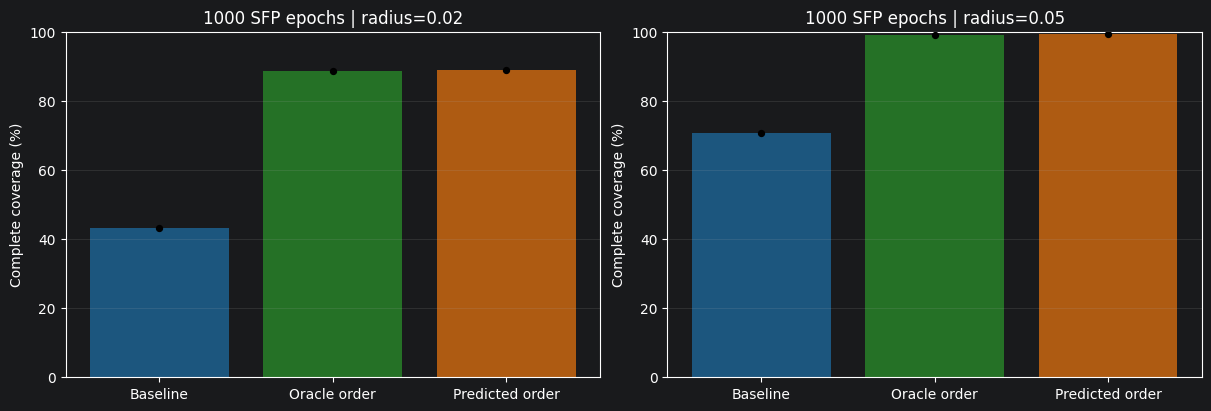

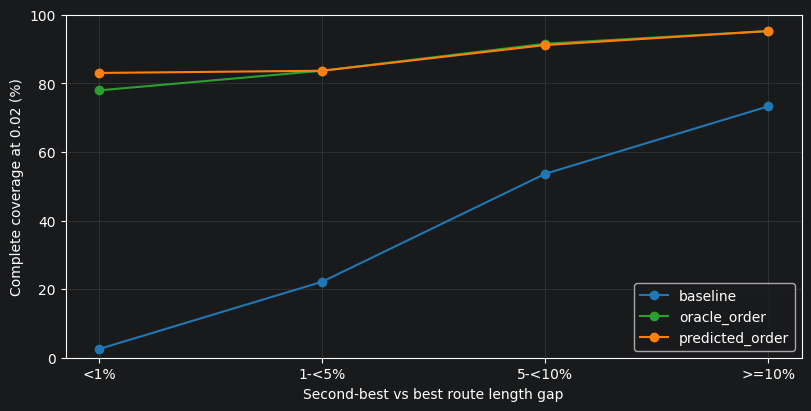

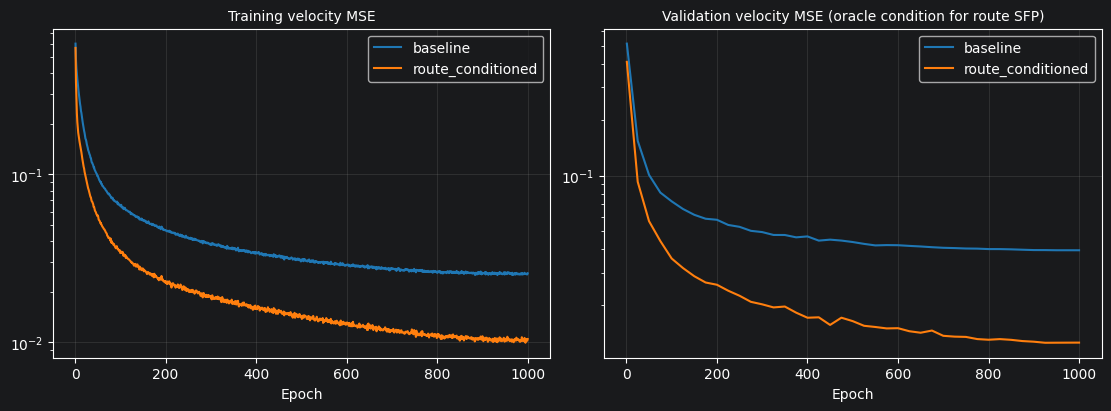

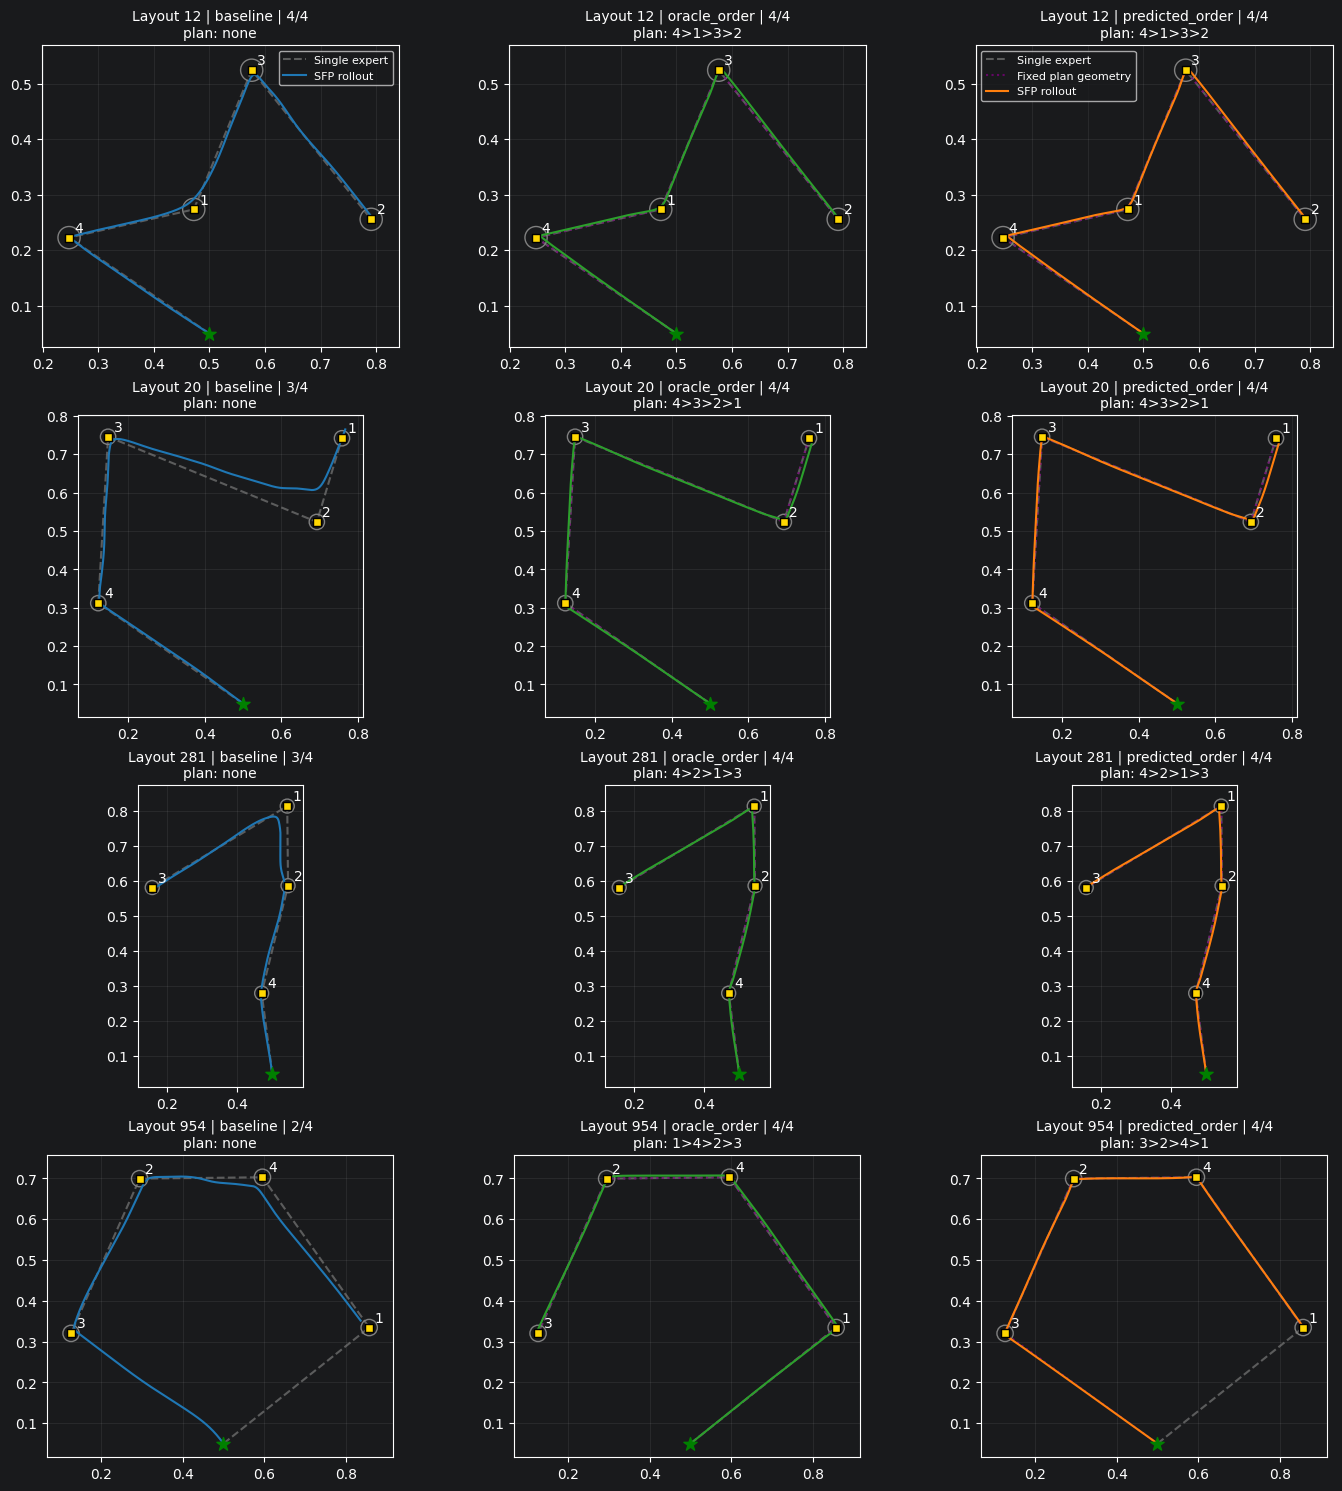

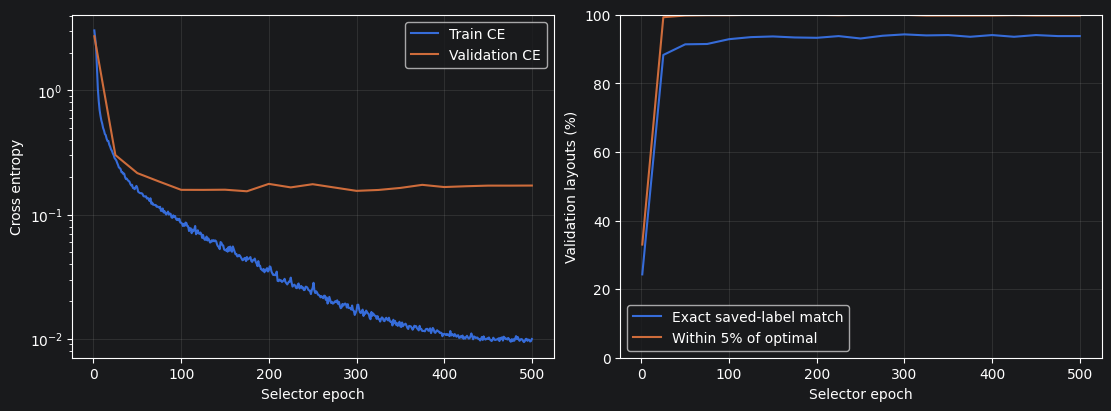

Finished. Share per_seed_summary.csv, selector_summary.csv, paired_changes.csv and the PNGs.
Output directory: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/single_route_choice_v1/reports/d37b312d17601c46


In [8]:
pair_rows=[]
for left,right in [('baseline','oracle_order'),('baseline','predicted_order'),('oracle_order','predicted_order')]:
    a=per_layout[per_layout['case']==left]; b=per_layout[per_layout['case']==right]
    paired=a.merge(b,on=['budget','seed','tolerance','layout_index'],suffixes=('_left','_right'),validate='one_to_one')
    for (budget,seed,tol),group in paired.groupby(['budget','seed','tolerance'],sort=False):
        for label in ['ALL',*GAP_LABELS]:
            g=group if label=='ALL' else group[group.gap_bin_left==label]
            if not len(g):
                continue
            ls,rs=g.success_left,g.success_right; both=g[ls & rs]
            pair_rows.append(dict(budget=budget,seed=seed,tolerance=tol,gap_bin=label,
                comparison=right+' minus '+left,n_layouts=len(g),rescued=int((~ls & rs).sum()),
                regressed=int((ls & ~rs).sum()),both_success=int((ls & rs).sum()),
                both_failure=int((~ls & ~rs).sum()),delta_success_pp=100*(rs.mean()-ls.mean()),
                common_success_length_ratio_delta=(both.path_length_ratio_right-both.path_length_ratio_left).mean(),
                common_success_completion_ratio_delta=(both.completion_length_ratio_right-both.completion_length_ratio_left).mean()))
paired_changes=pd.DataFrame(pair_rows)
paired_changes.to_csv(REPORT_DIR/'paired_changes.csv',index=False)
display(paired_changes[(paired_changes.gap_bin=='ALL')&(paired_changes.tolerance==.02)].reset_index(drop=True))

for budget in SFP_BUDGETS:
    fig,axes=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
    for ax,tol in zip(axes,[.02,.05]):
        for x,case in enumerate(CASES):
            g=per_seed[(per_seed.budget==budget)&(per_seed['case']==case)&
                (per_seed.tolerance==tol)&(per_seed.gap_bin=='ALL')]
            y=g.success_percent.to_numpy()
            ax.bar(x,y.mean(),color=COLORS[case],alpha=.65)
            offsets=np.zeros(1) if len(y)==1 else np.linspace(-.07,.07,len(y))
            ax.scatter(x+offsets,y,color='black',s=18,zorder=5)
            if len(y)>1:
                ax.errorbar(x,y.mean(),yerr=y.std(ddof=1),fmt='none',color='black',capsize=4)
        ax.set_xticks(range(3),['Baseline','Oracle order','Predicted order'])
        ax.set_ylim(0,100); ax.set_ylabel('Complete coverage (%)')
        ax.set_title(f'{budget} SFP epochs | radius={tol}'); ax.grid(axis='y',alpha=.2)
    fig.savefig(REPORT_DIR/f'success_{budget}.png',dpi=170); plt.show()

    fig,ax=plt.subplots(figsize=(8,4),constrained_layout=True)
    for case in CASES:
        g=aggregate[(aggregate.budget==budget)&(aggregate['case']==case)&(aggregate.tolerance==.02)]
        g=g.set_index('gap_bin').reindex(GAP_LABELS)
        ax.plot(range(4),g.success_mean_percent,'o-',label=case,color=COLORS[case])
        if len(SEEDS)>1:
            ax.errorbar(range(4),g.success_mean_percent,yerr=g.success_sd_pp,fmt='none',color=COLORS[case],capsize=3)
    ax.set_xticks(range(4),GAP_LABELS); ax.set_ylim(0,100); ax.grid(alpha=.2); ax.legend()
    ax.set_xlabel('Second-best vs best route length gap'); ax.set_ylabel('Complete coverage at 0.02 (%)')
    fig.savefig(REPORT_DIR/f'gap_success_{budget}.png',dpi=170); plt.show()

    fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
    for role,color in [('baseline',COLORS['baseline']),('route_conditioned',COLORS['predicted_order'])]:
        ckpt=torch.load(run_directory(role,budget,PLOT_SEED)/'final.pt',map_location='cpu',weights_only=True)
        h=ckpt.get('history',{}); train_loss=h.get('train_loss',[])
        axes[0].plot(h.get('epoch',list(range(1,len(train_loss)+1))),train_loss,label=role,color=color)
        probe=h.get('probe_loss',h.get('single_expert_probe_mse',h.get('validation_loss',[])))
        axes[1].plot(h.get('probe_epoch',list(range(1,len(probe)+1))),probe,label=role,color=color)
    for ax,title in zip(axes,['Training velocity MSE','Validation velocity MSE (oracle condition for route SFP)']):
        ax.set_title(title,fontsize=10); ax.set_xlabel('Epoch'); ax.set_yscale('log'); ax.grid(alpha=.2); ax.legend()
    fig.savefig(REPORT_DIR/f'sfp_loss_{budget}_seed_{PLOT_SEED}.png',dpi=170); plt.show()

    chosen=[i for i in FIXED_PLOT_LAYOUTS if 0<=i<len(VAL['starts'])]
    if chosen:
        selected={}
        for case in CASES:
            with np.load(ROLLOUT_FILES[(budget,PLOT_SEED,case)],allow_pickle=False) as z:
                selected[case]=z['paths'][chosen]
        fig,axes=plt.subplots(len(chosen),3,figsize=(14,3.7*len(chosen)),squeeze=False,constrained_layout=True)
        details=per_layout[(per_layout.budget==budget)&(per_layout.seed==PLOT_SEED)&(per_layout.tolerance==.02)]
        for row,i in enumerate(chosen):
            for col,case in enumerate(CASES):
                ax=axes[row,col]; path=selected[case][row]
                targets=VAL['targets'][i]; start=VAL['starts'][i]
                expert=VAL['routes'][i]
                ax.plot(expert[:,0],expert[:,1],'--',color='gray',alpha=.65,label='Single expert')
                info=details[(details.layout_index==i)&(details['case']==case)].iloc[0]
                if case!='baseline':
                    order=order_original(VAL,i,int(info.planned_class))
                    route=np.concatenate([start[None,:],targets[order]],axis=0)
                    ax.plot(route[:,0],route[:,1],':',color='purple',alpha=.75,label='Fixed plan geometry')
                ax.plot(path[:,0],path[:,1],color=COLORS[case],label='SFP rollout')
                ax.scatter(*start,marker='*',s=100,color='green',zorder=5)
                ax.scatter(targets[:,0],targets[:,1],marker='s',color='gold',edgecolors='black',zorder=5)
                for j,target in enumerate(targets):
                    ax.add_patch(plt.Circle(target,.02,fill=False,color='gray'))
                    ax.annotate(str(j+1),target,xytext=(4,4),textcoords='offset points')
                plan='none' if case=='baseline' else info.planned_order_original
                ax.set_title(f'Layout {i} | {case} | {info.visited_count}/4\nplan: {plan}',fontsize=10)
                ax.set_aspect('equal',adjustable='box'); ax.grid(alpha=.15)
        axes[0,0].legend(fontsize=8); axes[0,2].legend(fontsize=8)
        fig.savefig(REPORT_DIR/f'fixed_paths_{budget}_seed_{PLOT_SEED}.png',dpi=160); plt.show()

selector_ckpt=torch.load(run_directory('selector',SELECTOR_EPOCHS,PLOT_SEED)/'final.pt',map_location='cpu',weights_only=True)
h=selector_ckpt['history']
fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
axes[0].plot(h['epoch'],h['train_loss'],label='Train CE')
axes[0].plot(h['probe_epoch'],h['probe_loss'],label='Validation CE')
axes[0].set_ylabel('Cross entropy'); axes[0].set_yscale('log')
axes[1].plot(h['probe_epoch'],100*np.asarray(h['selector_accuracy']),label='Exact saved-label match')
axes[1].plot(h['probe_epoch'],100*np.asarray(h['selector_nearopt_rate']),label='Within 5% of optimal')
axes[1].set_ylabel('Validation layouts (%)'); axes[1].set_ylim(0,100)
for ax in axes:
    ax.set_xlabel('Selector epoch'); ax.grid(alpha=.2); ax.legend()
fig.savefig(REPORT_DIR/f'selector_training_seed_{PLOT_SEED}.png',dpi=170); plt.show()
print('Finished. Share per_seed_summary.csv, selector_summary.csv, paired_changes.csv and the PNGs.')
print('Output directory:',REPORT_DIR)


## 如何解读
- 首先看 `selector_summary.csv`：选择器在小 gap 布局中即使没有预测保存的唯一标签，也可能选中了近优顺序，二者不要混淆。
- 再看 `per_seed_summary.csv`：`baseline` 对比 `oracle_order` 检查提供明确路线信息后的执行变化；`predicted_order` 才是没有测试时专家路线的完整方法。
- Oracle 好、predicted 差时，结合预测顺序的长度和执行顺序一致率定位原因。可能是选路差，也可能是执行器不擅长当前布局下训练时没见过的近优顺序。
- 成功率提高但实际路程显著变长，说明覆盖改善了，最短路线问题仍未解决。使用 `paired_changes.csv` 的共同成功集合比较长度。
- 路线条件只是固定输入，不是强制路径约束；高顺序一致率也不代表从未出现几何偏移。
- 单 seed、1,000 epochs 只是试跑。训练尚未稳定时的阴性结果，不能直接否定路线条件的作用。
- 若需要原预算，把 `SFP_BUDGETS` 改为 `[10000]`，从头运行。完成模型会复用；不同预算模型独立训练。
- 输入数据与参数不变时，可将新实验目录连同原数据复制到另一台电脑后续训。原输出目录保留不动。

核心文件：`validation_per_layout.csv`（逐布局结果）、`per_seed_summary.csv`（分组结果）、
`selector_summary.csv`（选路质量）、`paired_changes.csv`（配对改善/退步）、训练曲线与固定布局轨迹 PNG。


Found 110 failures for predicted_order, budget=1000, seed=0, tol=0.02
Showing 12 cases (near_miss).


,layout_index,visited_count,worst_distance,gap_percent,planned_order_original,actual_first_entry_order_original,planned_excess_percent
0,137,3,0.020064,19.278032,1>4>2>3,1>4>3,0.000000
1,973,3,0.020102,3.727798,2>1>3>4,2>1>4,0.000000
2,882,3,0.020218,0.380485,4>2>1>3,4>2>1,0.000000
3,603,3,0.020364,5.108552,2>1>4>3,2>1>4,0.000000
4,920,3,0.020398,9.341625,3>1>2>4,3>1>4,0.000000
5,930,3,0.020729,2.734794,4>2>3>1,4>3>1,0.000000
6,363,3,0.020872,0.729496,4>1>3>2,4>3>2,0.000000
7,963,3,0.020905,11.362472,1>4>2>3,4>2>3,0.000000
8,666,3,0.020914,6.287184,3>1>4>2,3>1>2,0.000000
9,53,3,0.020942,3.842687,4>1>2>3,4>1>2,0.000000


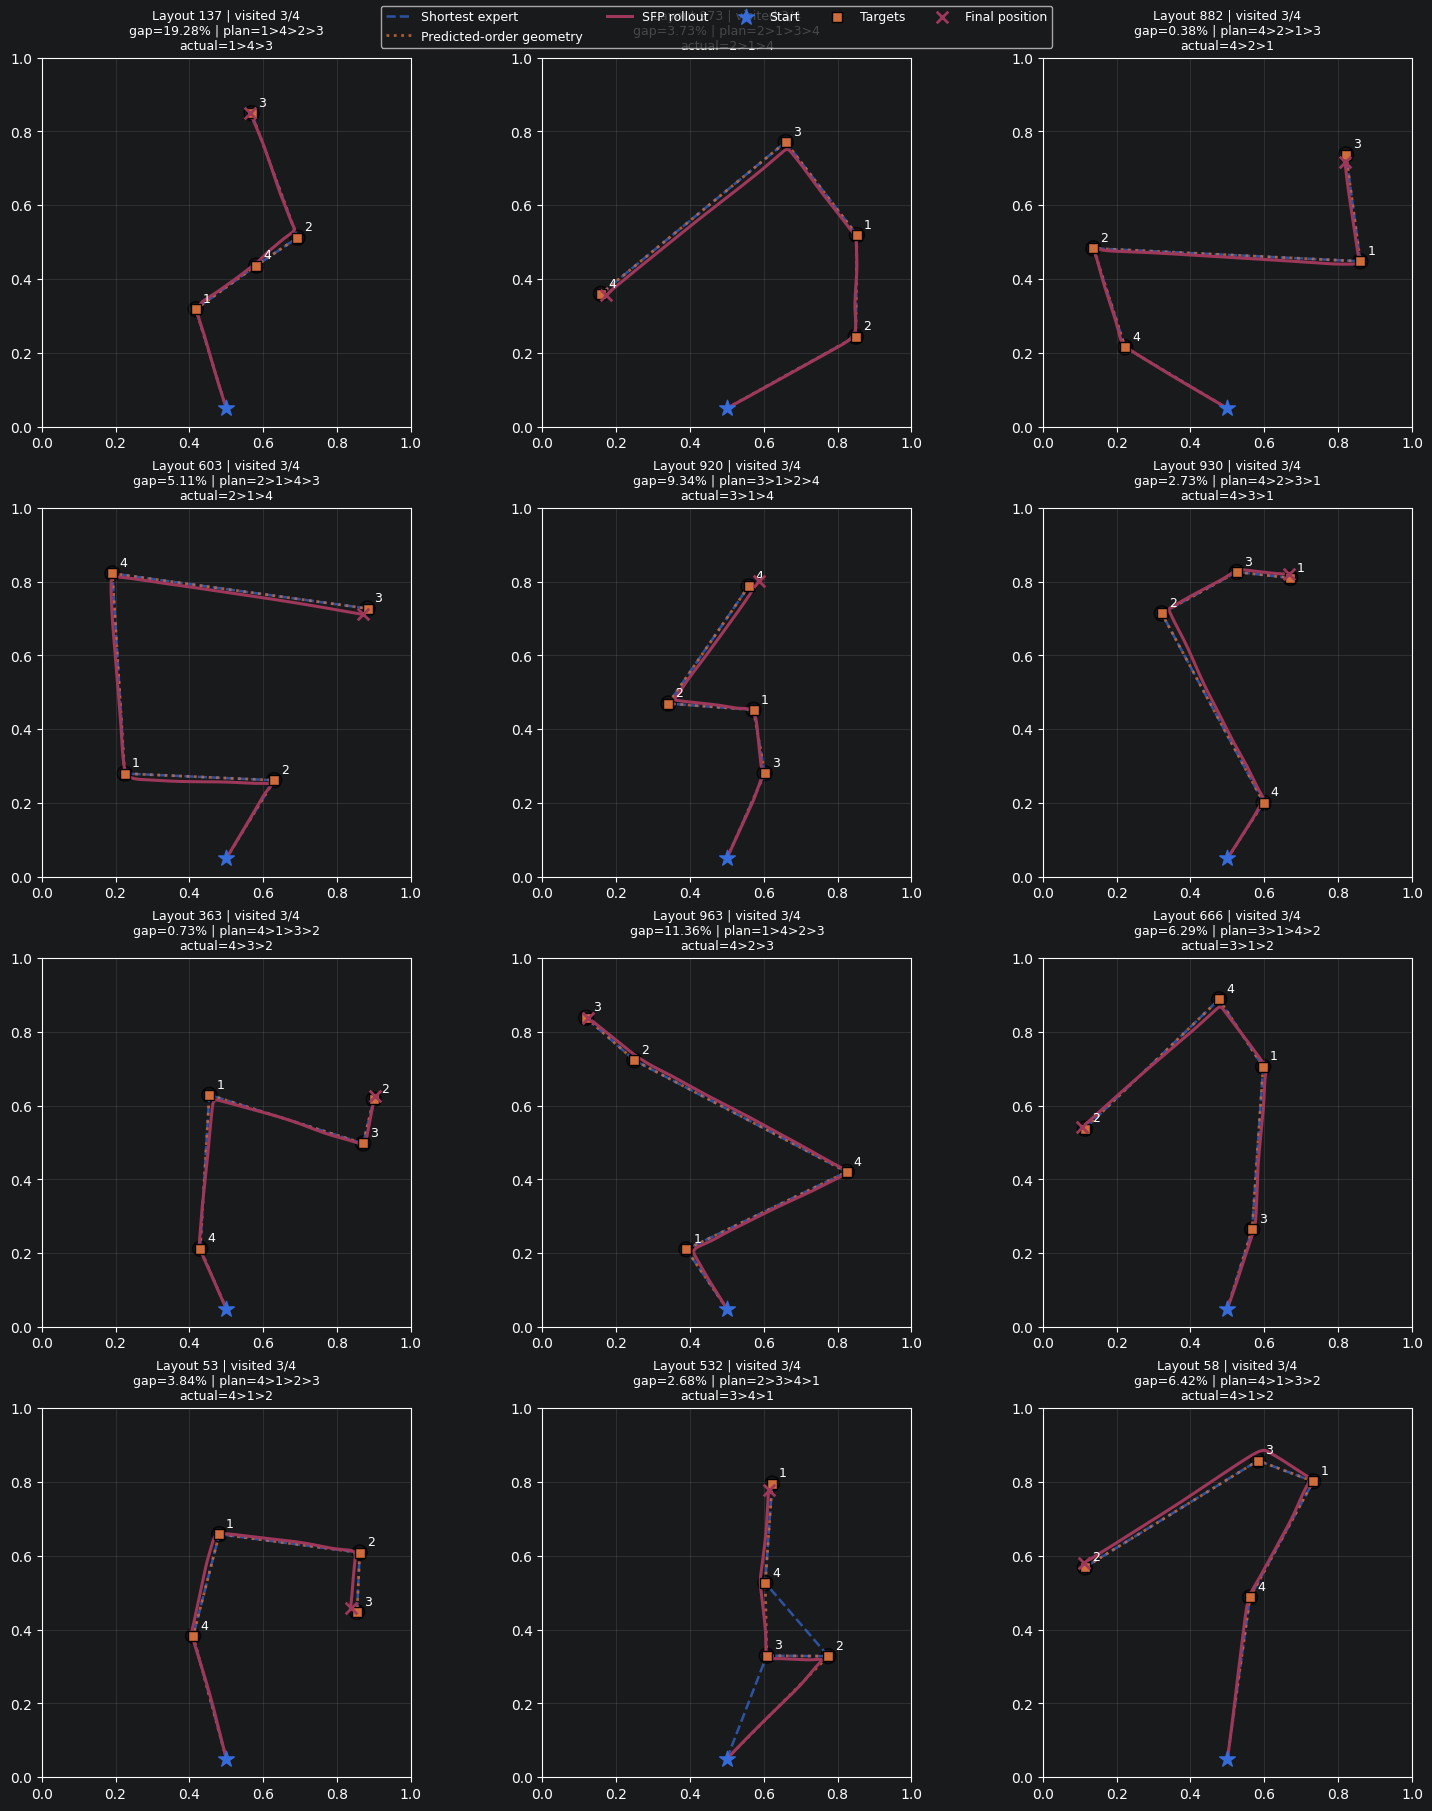

In [9]:
# ============================================================
# Visualise failed predicted-order cases
# Run this AFTER the evaluation/report cells above
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----- Settings -----
CASE = "predicted_order"
TOL = 0.02

# Use the latest/current SFP budget in this notebook
BUDGET = SFP_BUDGETS[-1]
SEED = PLOT_SEED

N_SHOW = 12

# "first"     = lowest layout indices
# "near_miss" = failures that came closest to succeeding
# "worst"     = most severe failures
SORT_MODE = "near_miss"


# ============================================================
# 1. Find failures
# ============================================================

failures = per_layout[
    (per_layout["budget"] == BUDGET)
    & (per_layout["seed"] == SEED)
    & (per_layout["case"] == CASE)
    & (per_layout["tolerance"] == TOL)
    & (~per_layout["success"])
].copy()

if SORT_MODE == "near_miss":
    # Prefer cases that already visited many targets,
    # then those with smaller remaining miss distance.
    failures = failures.sort_values(
        ["visited_count", "worst_distance"],
        ascending=[False, True],
    )

elif SORT_MODE == "worst":
    failures = failures.sort_values(
        ["visited_count", "worst_distance"],
        ascending=[True, False],
    )

else:
    failures = failures.sort_values("layout_index")

failures = failures.head(N_SHOW)

# Count all failed cases before taking head(N_SHOW)
all_failures = per_layout[
    (per_layout["budget"] == BUDGET)
    & (per_layout["seed"] == SEED)
    & (per_layout["case"] == CASE)
    & (per_layout["tolerance"] == TOL)
    & (~per_layout["success"])
]

num_failures = len(all_failures)

print(
    f"Found {num_failures} failures "
    f"for {CASE}, budget={BUDGET}, seed={SEED}, tol={TOL}"
)

print(
    f"Showing {len(failures)} cases ({SORT_MODE})."
)

display(
    failures[
        [
            "layout_index",
            "visited_count",
            "worst_distance",
            "gap_percent",
            "planned_order_original",
            "actual_first_entry_order_original",
            "planned_excess_percent",
        ]
    ].reset_index(drop=True)
)


# ============================================================
# 2. Load rollout trajectories
# ============================================================

rollout_file = ROLLOUT_FILES[(BUDGET, SEED, CASE)]

with np.load(rollout_file, allow_pickle=False) as z:
    all_paths = z["paths"]


# ============================================================
# 3. Plot
# ============================================================

n = len(failures)

if n == 0:
    print("No failed cases found.")

else:
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4.5 * nrows),
        squeeze=False,
        constrained_layout=True,
    )

    axes = axes.ravel()

    for ax_idx, (_, info) in enumerate(failures.iterrows()):

        ax = axes[ax_idx]

        i = int(info["layout_index"])

        start = VAL["starts"][i]
        targets = VAL["targets"][i]
        expert = VAL["routes"][i]
        path = all_paths[i]

        # ----------------------------------------------------
        # True shortest expert route
        # ----------------------------------------------------
        ax.plot(
            expert[:, 0],
            expert[:, 1],
            "--",
            linewidth=1.8,
            alpha=0.7,
            label="Shortest expert",
        )

        # ----------------------------------------------------
        # Predicted fixed route/order
        # ----------------------------------------------------
        planned_class = int(info["planned_class"])
        planned_order = order_original(
            VAL,
            i,
            planned_class,
        )

        planned_route = np.concatenate(
            [
                start[None, :],
                targets[planned_order],
            ],
            axis=0,
        )

        ax.plot(
            planned_route[:, 0],
            planned_route[:, 1],
            ":",
            linewidth=2.0,
            alpha=0.8,
            label="Predicted-order geometry",
        )

        # ----------------------------------------------------
        # Actual learned SFP rollout
        # ----------------------------------------------------
        ax.plot(
            path[:, 0],
            path[:, 1],
            linewidth=2.2,
            label="SFP rollout",
        )

        # Starting point
        ax.scatter(
            start[0],
            start[1],
            marker="*",
            s=140,
            zorder=6,
            label="Start",
        )

        # Targets + tolerance circles
        ax.scatter(
            targets[:, 0],
            targets[:, 1],
            marker="s",
            s=55,
            edgecolors="black",
            zorder=6,
            label="Targets",
        )

        for j, target in enumerate(targets):

            circle = plt.Circle(
                target,
                TOL,
                fill=False,
                linewidth=1.2,
                alpha=0.7,
            )

            ax.add_patch(circle)

            ax.annotate(
                str(j + 1),
                target,
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=9,
            )

        # Final rollout position
        ax.scatter(
            path[-1, 0],
            path[-1, 1],
            marker="x",
            s=70,
            linewidths=2,
            zorder=7,
            label="Final position",
        )

        # ----------------------------------------------------
        # Information in title
        # ----------------------------------------------------
        plan_text = info["planned_order_original"]
        actual_text = info["actual_first_entry_order_original"]

        ax.set_title(
            f"Layout {i} | visited {int(info['visited_count'])}/4\n"
            f"gap={info['gap_percent']:.2f}% | "
            f"plan={plan_text}\n"
            f"actual={actual_text}",
            fontsize=9,
        )

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.2)

    # Hide unused panels
    for j in range(n, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=5,
        fontsize=9,
    )

    plt.show()